# 3. EDA

Looking at the cleaned data to see how spam and ham messages differ. I'll use the original `message` column for lengths (so punctuation is counted) and `clean_message` for the word counts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid')
colors = {'ham': '#4c78a8', 'spam': '#e45756'}

In [2]:
df = pd.read_csv('data/spam_clean.csv')
print(df.shape)
df.head(3)

(5126, 4)


,label,label_num,message,clean_message
0,ham,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...


## How many spam and ham messages are there?

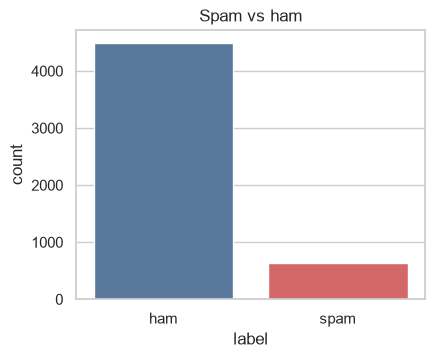

label
ham     87.7
spam    12.3
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(4.5, 3.5))
sns.countplot(data=df, x='label', hue='label', order=['ham', 'spam'], palette=colors, legend=False)
plt.title('Spam vs ham')
plt.show()

print((df['label'].value_counts(normalize=True) * 100).round(1))

About 88% ham and 12% spam after removing duplicates.

## Are spam messages longer?

In [4]:
df['char_count'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()

df.groupby('label')[['char_count', 'word_count']].agg(['mean', 'median', 'max']).round(1)

char_count             word_count            
            mean median  max       mean median  max
label                                              
ham         70.7   53.0  910       14.2   11.0  171
spam       137.5  148.0  224       23.6   25.0   35

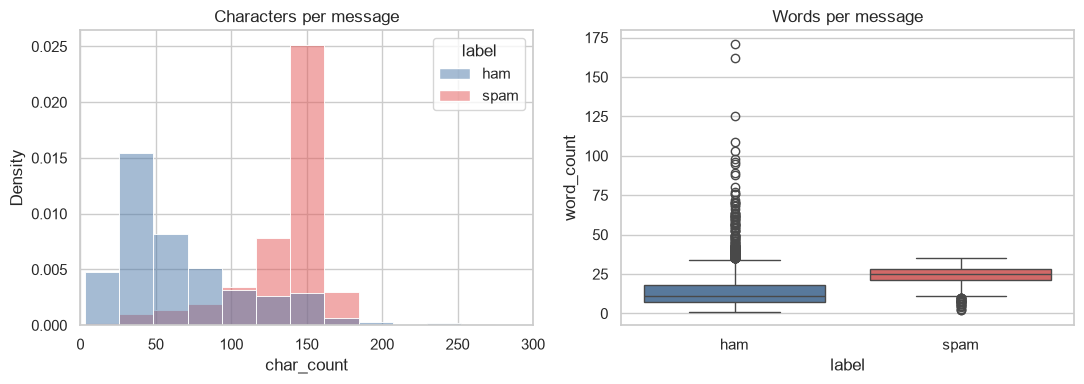

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=df, x='char_count', hue='label', bins=40, stat='density',
             common_norm=False, palette=colors, ax=axes[0])
axes[0].set_xlim(0, 300)   # a few ham messages are much longer, cut for readability
axes[0].set_title('Characters per message')

sns.boxplot(data=df, x='label', y='word_count', hue='label', order=['ham', 'spam'],
            palette=colors, legend=False, ax=axes[1])
axes[1].set_title('Words per message')

plt.tight_layout()
plt.show()

Yes. Spam messages are longer, around 150 characters and 25 words in the middle, while half of the ham messages are under 53 characters. Spam is also very consistent (nothing above 224 characters), while ham has a long tail (30 messages are longer than 300 characters, up to 910).

Length looks like a useful signal, but the models will only see the words. That's fine for now.

## Numbers and capital letters

Spam messages seem to contain a lot of phone numbers and prices. Checking that, and also checking capital letters since the cleaning step made everything lowercase.

In [6]:
df['digit_count'] = df['message'].str.count(r'\d')
df['capital_count'] = df['message'].str.count(r'[A-Z]')
df['has_long_number'] = df['message'].str.contains(r'\d{5,}')

print('Average per message')
print(df.groupby('label')[['digit_count', 'capital_count']].mean().round(1))
print()
print('Share of messages with a number of 5+ digits')
print(df.groupby('label')['has_long_number'].mean().round(3))

Average per message
       digit_count  capital_count
label                            
ham            0.3            3.8
spam          15.4           15.1

Share of messages with a number of 5+ digits
label
ham     0.001
spam    0.765
Name: has_long_number, dtype: float64


This is a big difference. About 76% of spam messages have a long number (phone number or short code) compared to almost none of the ham messages. So keeping the digits in preprocessing was the right call.

Spam also has about four times more capital letters ("WINNER", "URGENT", "FREE"). This information is lost when the text is lowercased, but the words themselves should still carry most of the signal.

## What words are most common?

Stopwords are left out here just to make the charts readable. This is only for looking at the data, the models later will use their own vectorizer.

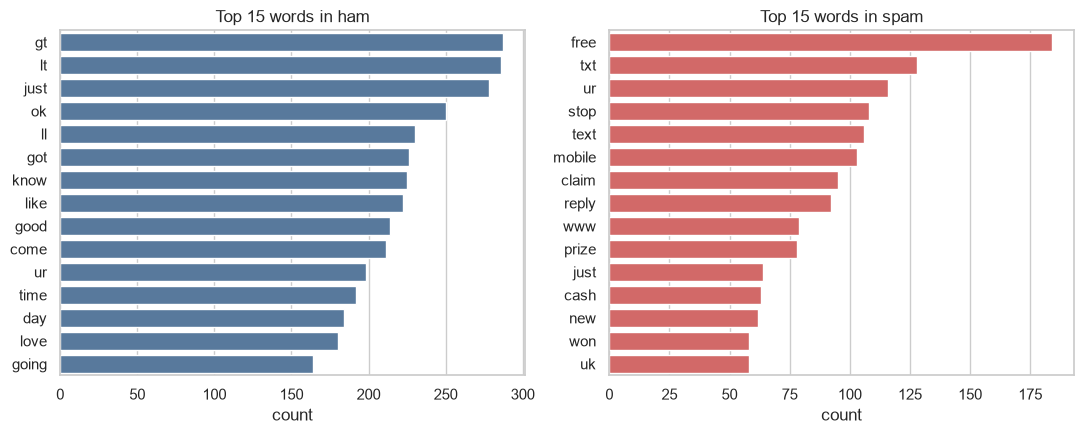

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, label in zip(axes, ['ham', 'spam']):
    texts = df[df['label'] == label]['clean_message']

    vectorizer = CountVectorizer(stop_words='english')
    counts = vectorizer.fit_transform(texts)
    word_counts = pd.Series(counts.sum(axis=0).A1, index=vectorizer.get_feature_names_out())
    top_words = word_counts.sort_values(ascending=False).head(15)

    sns.barplot(x=top_words.values, y=top_words.index, color=colors[label], ax=ax)
    ax.set_title('Top 15 words in ' + label)
    ax.set_xlabel('count')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Spam words are what you would expect: free, txt, mobile, stop, reply, claim, prize, cash, won. Ham words are everyday chat (ok, know, good, love, time). The ham chart also has `gt` and `lt`, which come from `&lt;#&gt;` in the original messages.

## Summary

- The data is imbalanced (12% spam), so accuracy alone is not enough. I'll look at precision, recall and F1.
- Spam is longer and full of numbers, capital letters and words like free, claim, prize.
- The word choice is clearly different between the two classes, so a bag-of-words model should work well here.